In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r "/content/drive/MyDrive/Summer 2026/FinalProjectDL/Images" /content/Images

In [4]:
import os
print(os.listdir("/content/Images")[:5])
print(len(os.listdir("/content/Images")))  # should be 120 breed folders


['n02104365-schipperke', 'n02102480-Sussex_spaniel', 'n02094433-Yorkshire_terrier', 'n02088632-bluetick', 'n02107142-Doberman']
121


In [5]:
print(os.listdir("/content/Images"))

['n02104365-schipperke', 'n02102480-Sussex_spaniel', 'n02094433-Yorkshire_terrier', 'n02088632-bluetick', 'n02107142-Doberman', 'n02086079-Pekinese', 'n02098286-West_Highland_white_terrier', 'n02088094-Afghan_hound', 'n02087046-toy_terrier', 'n02098105-soft-coated_wheaten_terrier', 'n02111500-Great_Pyrenees', 'n02107683-Bernese_mountain_dog', 'n02106166-Border_collie', 'n02097298-Scotch_terrier', 'n02093256-Staffordshire_bullterrier', 'n02091244-Ibizan_hound', 'n02113799-standard_poodle', 'n02094114-Norfolk_terrier', 'n02096294-Australian_terrier', 'n02112706-Brabancon_griffon', 'n02096585-Boston_bull', 'n02098413-Lhasa', 'n02097658-silky_terrier', 'n02086910-papillon', 'n02100236-German_short-haired_pointer', 'n02093754-Border_terrier', 'n02085782-Japanese_spaniel', 'n02100735-English_setter', 'n02095570-Lakeland_terrier', 'n02110185-Siberian_husky', 'n02101006-Gordon_setter', 'n02091831-Saluki', 'n02096437-Dandie_Dinmont', 'n02106550-Rottweiler', 'n02095889-Sealyham_terrier', 'n02088

In [6]:
!rm -f /content/Images/.DS_Store
print(len(os.listdir("/content/Images")))

120


In [7]:
#!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib

In [8]:
import torchvision
from torch.utils.data import random_split

full_dataset = torchvision.datasets.ImageFolder(root="/content/Images")
class_names = [name.split("-", 1)[1].replace("_", " ") for name in full_dataset.classes]

print(f"{len(full_dataset)} total images, {len(class_names)} breeds")
print(class_names[:10])

20580 total images, 120 breeds
['Chihuahua', 'Japanese spaniel', 'Maltese dog', 'Pekinese', 'Shih-Tzu', 'Blenheim spaniel', 'papillon', 'toy terrier', 'Rhodesian ridgeback', 'Afghan hound']


In [9]:
from transformers import ViTImageProcessor, ViTForImageClassification

train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

id2label = {str(i): name for i, name in enumerate(class_names)}
label2id = {name: str(i) for i, name in enumerate(class_names)}

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(class_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

Train: 17493, Val: 3087


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=120` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([120, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([120])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [10]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [11]:
def transform_example(example):
    image, label = example
    inputs = processor(images=image.convert("RGB"), return_tensors="pt")
    return {"pixel_values": inputs["pixel_values"][0], "labels": label}

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        return transform_example(self.subset[idx])

train_transformed = TransformedDataset(train_ds)
val_transformed = TransformedDataset(val_ds)

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

In [14]:
#!pip install -q evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00


In [15]:
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir="/content/vit-dog-breed",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    remove_unused_columns=False,
    report_to="none",
    fp16=True,  # speeds up training on GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_transformed,
    eval_dataset=val_transformed,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.764112,0.700082,0.833819
2,0.265186,0.507373,0.861030
3,0.112293,0.474108,0.867509
4,0.036313,0.461896,0.873016


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=2188, training_loss=0.6958900399683162, metrics={'train_runtime': 1086.2723, 'train_samples_per_second': 64.415, 'train_steps_per_second': 2.014, 'total_flos': 5.428004071510573e+18, 'train_loss': 0.6958900399683162, 'epoch': 4.0})

In [17]:
trainer.save_model("/content/drive/MyDrive/vit-dog-breed")
processor.save_pretrained("/content/drive/MyDrive/vit-dog-breed")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/vit-dog-breed/preprocessor_config.json']

In [19]:
#!pip install -q scikit-learn matplotlib

In [20]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []

loader = torch.utils.data.DataLoader(val_transformed, batch_size=32, collate_fn=collate_fn)

with torch.no_grad():
    for batch in loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]
        outputs = model(pixel_values=pixel_values)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

                                precision    recall  f1-score   support

                     Chihuahua      0.741     0.833     0.784        24
              Japanese spaniel      0.938     0.938     0.938        32
                   Maltese dog      0.900     0.900     0.900        40
                      Pekinese      0.929     0.765     0.839        17
                      Shih-Tzu      0.897     0.963     0.929        27
              Blenheim spaniel      0.909     0.909     0.909        22
                      papillon      1.000     0.971     0.985        34
                   toy terrier      0.923     0.750     0.828        32
           Rhodesian ridgeback      0.808     0.778     0.792        27
                  Afghan hound      1.000     0.939     0.969        33
                        basset      0.897     0.897     0.897        29
                        beagle      0.724     0.840     0.778        25
                    bloodhound      0.933     0.737     0.824  

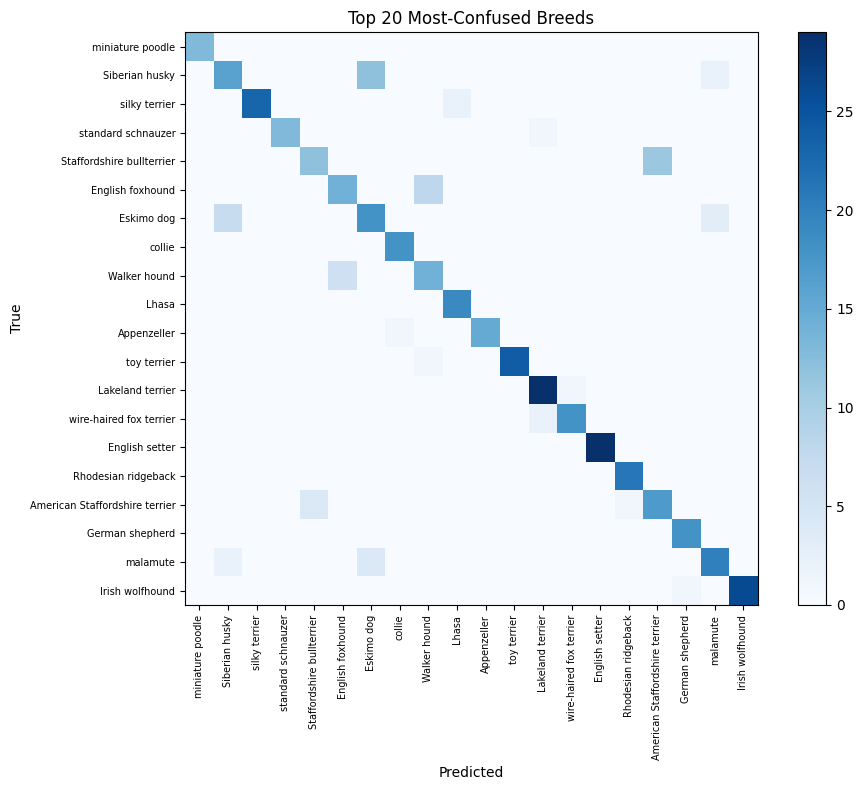

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

# focus on the most-confused classes for readability
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
worst_classes = np.argsort(off_diag.sum(axis=1))[::-1][:20]

sub_cm = cm[np.ix_(worst_classes, worst_classes)]
sub_labels = [class_names[i] for i in worst_classes]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub_cm, cmap="Blues")
ax.set_xticks(range(len(sub_labels)))
ax.set_yticks(range(len(sub_labels)))
ax.set_xticklabels(sub_labels, rotation=90, fontsize=7)
ax.set_yticklabels(sub_labels, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Top 20 Most-Confused Breeds")
fig.colorbar(im)
fig.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=150)
plt.show()

In [22]:
!zip -r /content/drive/MyDrive/vit-dog-breed.zip /content/drive/MyDrive/vit-dog-breed

  adding: content/drive/MyDrive/vit-dog-breed/ (stored 0%)
  adding: content/drive/MyDrive/vit-dog-breed/config.json (deflated 68%)
  adding: content/drive/MyDrive/vit-dog-breed/model.safetensors (deflated 7%)
  adding: content/drive/MyDrive/vit-dog-breed/training_args.bin (deflated 53%)
  adding: content/drive/MyDrive/vit-dog-breed/preprocessor_config.json (deflated 47%)
